**Train the Model for Spam / Ham Emails using Logistic Regression Algorithm**

**Description of Spam/Ham Datadet**

I download the Dataset from Kaggle.com
***About Dataset***
The Spam Assassin Dataset is a a selection of mail messages, suitable for use in testing spam filtering systems. https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [74]:
import numpy as np
import pandas as pd

In [75]:
# loading the dataset
df = pd.read_csv("/content/drive/MyDrive/SpamHamModel/spam.csv",
                 encoding="latin1")
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


**1-Data Cleaning**

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [77]:
# delete the unnecessary columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.head(3)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [78]:
# Rename the columns for better under standing of Data that it contain
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.head(3)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [79]:
# Encode Spam=1 and Ham=0
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [80]:
# Checking - How many rows and columns?
print(df.shape)

(5572, 2)


In [81]:
# Checking - How many missing values?
df.isnull().sum()

,0
target,0
text,0


In [82]:
# Delete the rows which have any missing value
df.dropna(axis=0, inplace=True)

In [83]:
# # Checking - How many rows and columns?
print(df.shape)

(5572, 2)


In [84]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [85]:
# reomve the duplicate values
df = df.drop_duplicates(keep='first')

In [86]:
# Again Check duplacate values
df.duplicated().sum()

np.int64(0)

In [87]:
# Again Checking - How many rows and columns?
print(df.shape)

(5169, 2)


In [88]:
# Print the first record of dataset for observation
print(df.iloc[0]['text'])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


**EDA - Exploratory Data Analysis**

In [89]:
# count the no of values of Spam & Ham
df['target'].value_counts()

,count
target,
0,4516
1,653


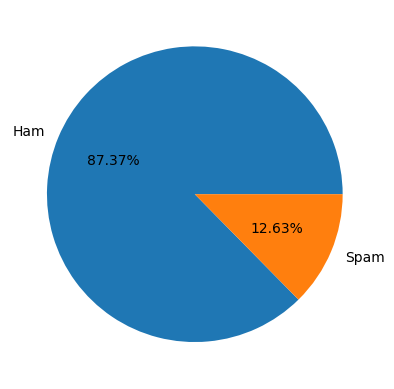

In [90]:
# Draw a pie chart which represent % of ham & spam
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['Ham' , 'Spam'], autopct="%0.2f%%")
plt.show()

In [91]:
# Data is imbalance because Ham is 87.37% and Spam 12.63%

In [92]:
# Now find no. of sentences, no of words, no of characters in messages
!pip install nltk

In [93]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [94]:
# no of numeric characters
df['numeric_characters']= df['text'].apply(len)
df.head(3)

,target,text,numeric_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155


In [95]:
# find no of words
from nltk.tokenize import word_tokenize
df['no_words'] = df['text'].apply(lambda x:len(word_tokenize(x)))
df.head(3)


,target,text,numeric_characters,no_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37


In [96]:
# find no of sentences
df['no_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head(3)

,target,text,numeric_characters,no_words,no_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2


In [97]:
# Analysis of columns numeric_characters, no_word , no_sentences
df[['numeric_characters' , 'no_words' , 'no_sentences']].describe()

,numeric_characters,no_words,no_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [98]:
# analysis of Spam messages
df[df['target'] == 1][['numeric_characters' , 'no_words' , 'no_sentences']].describe()

,numeric_characters,no_words,no_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [99]:
# analysis of Ham messages
df[df['target'] == 0][['numeric_characters' , 'no_words' , 'no_sentences']].describe()

,numeric_characters,no_words,no_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [100]:
# Observe that :: no of characters,word,sentences in Spam messages more than no of characetrs,words,sentences in Ham messgaes

<Axes: xlabel='numeric_characters', ylabel='Count'>

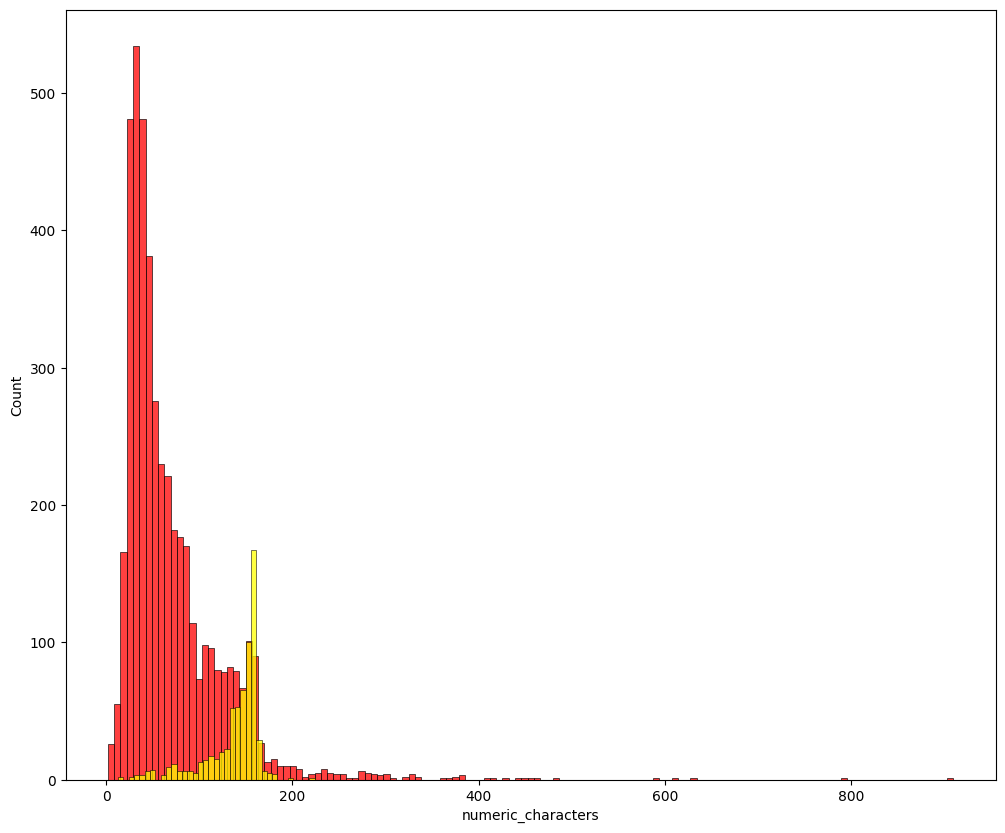

In [101]:
# Analysis by Histogram :: no of characters
import seaborn as sns
plt.figure(figsize = (12,10))
sns.histplot(df[df['target'] == 0]['numeric_characters'], color = 'red')
sns.histplot(df[df['target'] == 1]['numeric_characters'], color = 'yellow')

In [102]:
# observe that :: no of characters in Spam messages more than no of characetrs in Ham messages

<Axes: xlabel='no_words', ylabel='Count'>

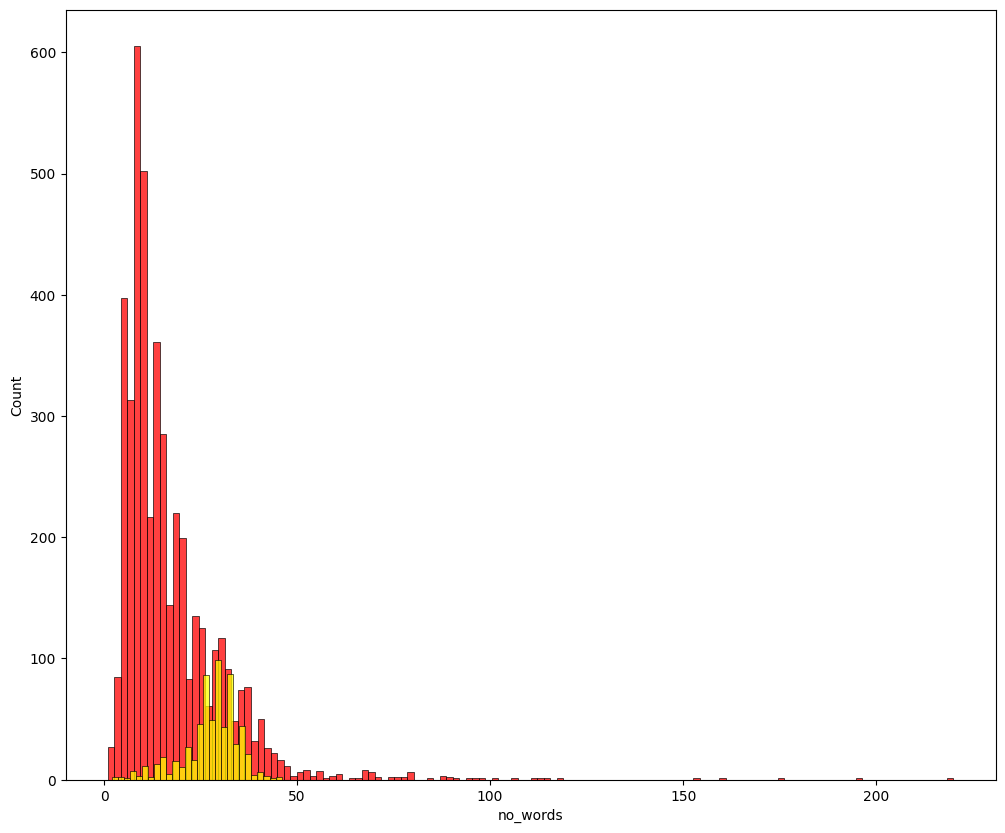

In [103]:
# Analysis by Histogram :: no of words
plt.figure(figsize = (12,10))
sns.histplot(df[df['target'] == 0]['no_words'], color = 'red')
sns.histplot(df[df['target'] == 1]['no_words'], color = 'yellow')

In [104]:
# observe that :: no of words in Spam messages more than no of words in Ham messages

<Axes: xlabel='no_sentences', ylabel='Count'>

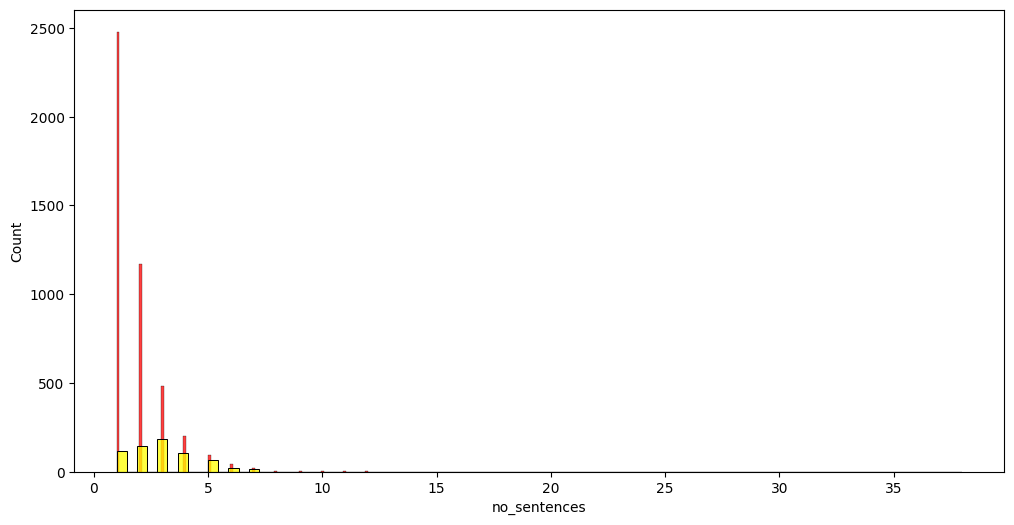

In [105]:
# Analysis by Histogram :: no of sentences
plt.figure(figsize = (12,6))
sns.histplot(df[df['target'] == 0]['no_sentences'], color = 'red')
sns.histplot(df[df['target'] == 1]['no_sentences'], color = 'yellow')

In [106]:
# observe that :: no of sentences in Spam messages more than no of sentences in Ham messages

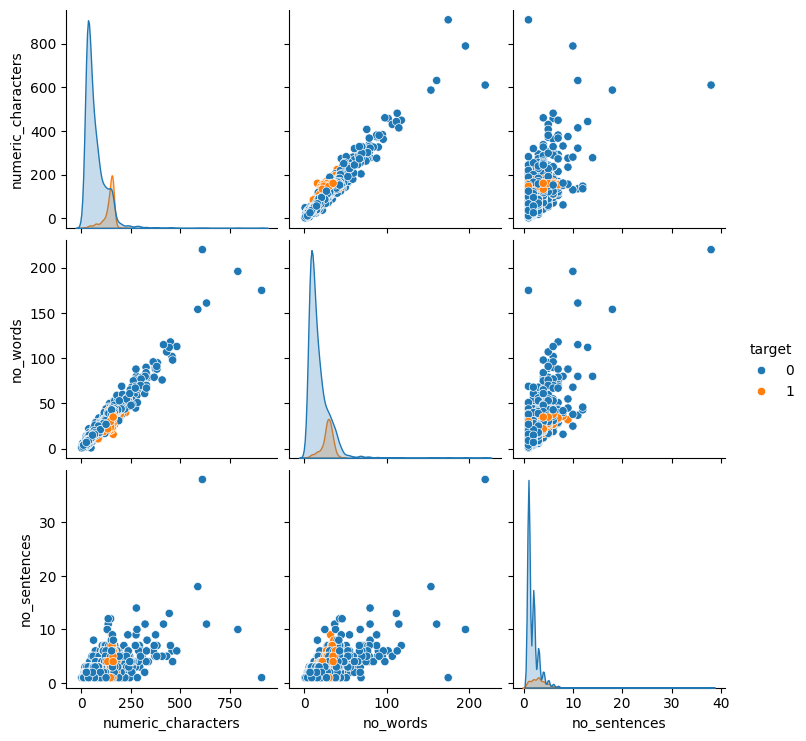

In [107]:
# find the relationship between 3 columns no_word, numeric_characters, no_sentences by pair graph
sns.pairplot(df,hue='target')

In [108]:
# observation : strong +ve correlation between numeric_characters and no_words means - messages contain more words and more characters
# spam messgaes are clustered at higher values of numeric_characters, no_words, and no_sentences
# there are some messages overlap between Spam nad Ham , but spam messages are more concentrated in the higher ranges of these features

In [109]:
df.columns

Index(['target', 'text', 'numeric_characters', 'no_words', 'no_sentences'], dtype='object')

In [110]:
# find correlation (+ve / -ve relationship between columns)
df[['target','numeric_characters', 'no_words', 'no_sentences']].astype(int)
df[['target','numeric_characters', 'no_words', 'no_sentences']].corr()
#sns.heatmap(df.corr(),annot=True)

,target,numeric_characters,no_words,no_sentences
target,1.000000,0.384717,0.262912,0.263939
numeric_characters,0.384717,1.000000,0.965760,0.624139
no_words,0.262912,0.965760,1.000000,0.679971
no_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

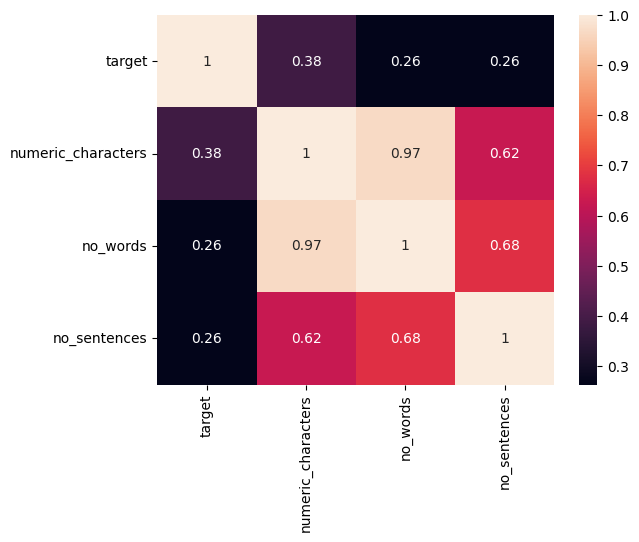

In [111]:
sns.heatmap(df[['target','numeric_characters', 'no_words', 'no_sentences']]
            .corr(), annot=True)

In [112]:
#observations : numeric_characters and no_words have a very strong positive correlation (0.97), meaning messages with more words almost always contain more characters.
#no_sentences has a moderate positive correlation with numeric_characters (0.62) and no_words (0.68), indicating that longer messages tend to have more sentences.
#The target column has a weak positive correlation with all three features (0.26–0.38), suggesting that spam messages are generally longer, but these features alone are not sufficient for perfect classification.

**I go for Best feature: numeric_characters (highest correlation with target = 0.38) Also useful: no_words**

**2-Data Processing**

In [113]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
stopwords.words('english')
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [114]:
# Function for text processing
def text_processing_f(text):

    # 1-convert to lower case
    text = text.lower()

    # 2-Tokenize the words
    text = nltk.word_tokenize(text)

    # remove the special characters
    text = [word for word in text if word.isalnum()]

    #3-remove stopwords(eg a,is,the,for,on etc)
    # remove Punctuations(!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~)
    text = [word for word in text
           if word not in stopwords.words('english') and
            word not in string.punctuation]

    # 6-Stemming (eg. Dance,Dancing,danced convert to dance)
    text = [ps.stem(word) for word in text]


    return " ".join(text)

**Check text_processing_f  FUNCTION**

In [115]:
text_processing_f('Where the Lahori looking %%  & # 3446 ? ')


'lahori look 3446'

In [116]:
df['text'][3000]
#I sent you  &lt;#&gt;  bucks

'This message is free. Welcome to the new & improved Sex & Dogging club! To unsubscribe from this service reply STOP. msgs@150p 18+only'

In [117]:
df['processed_text'] = df['text'].apply(text_processing_f)

In [118]:
df.head(5)

,target,text,numeric_characters,no_words,no_sentences,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Generate the word cloud of Spam Messages & Not Spam Messages**

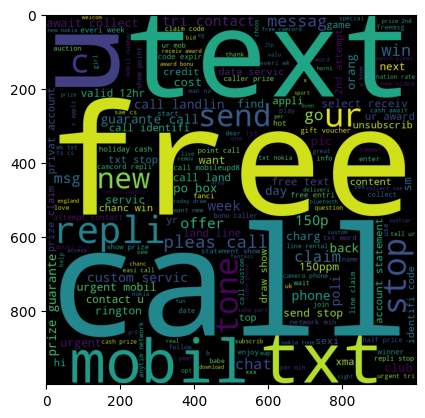

In [119]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
wc = WordCloud(
            width=1000,
            height=1000,
            min_font_size=12,
            background_color='black'
            )
spam_wc = wc.generate(df[df['target']==1]['processed_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

In [120]:
#observation :: free, call, txt, claim, reply, and win, indicating that spam messages

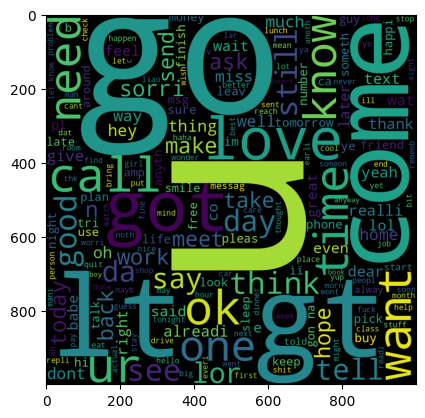

In [121]:
not_spam_wc=wc.generate(df[df['target']==0]['processed_text'].str.cat(sep=' '))
plt.imshow(not_spam_wc)

In [122]:
# #obsevation :: ok, will, call, now, and go, indicating that most ham messages

**Find Top 20 common words of spam messages**

In [123]:
# find how many words in spam messages?
spam_top_w = []
# convert all processed text messages in list
for msg in df[df['target']==1]['processed_text'].tolist():
    for word in msg.split():
        spam_top_w.append(word)
len(spam_top_w)

9939

In [124]:
# list of top 20 spam words
from collections import Counter
df_spam_top_w = pd.DataFrame(Counter(spam_top_w).most_common(20))
print(df_spam_top_w)

         0    1
0     call  320
1     free  191
2        2  155
3      txt  141
4     text  122
5        u  119
6       ur  119
7    mobil  114
8     stop  104
9    repli  103
10   claim   98
11       4   97
12   prize   82
13     get   74
14     new   64
15  servic   64
16    tone   63
17    send   60
18  urgent   57
19   nokia   57


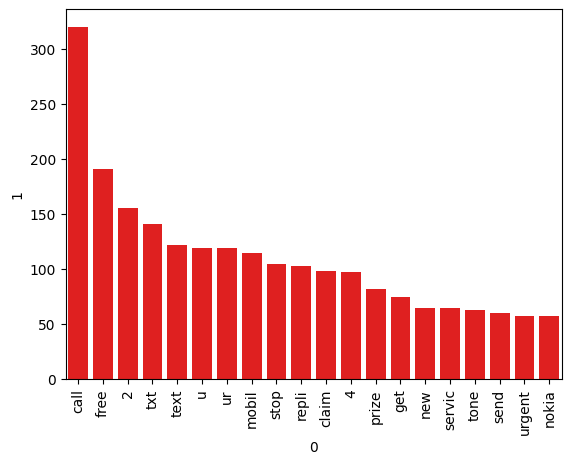

In [125]:
import seaborn as sns
sns.barplot(x=0,y=1,data=df_spam_top_w, color='red')
plt.xticks(rotation = 'vertical')
plt.show()

**Find Top 30 common words of ham messages**

In [126]:
# find how many words in spam messages?
ham_top_w = []
# convert all processed text messages in list
for msg in df[df['target']==0]['processed_text'].tolist():
    for word in msg.split():
        ham_top_w.append(word)
len(ham_top_w)

35404

In [127]:
# list of top 20 ham words
from collections import Counter
df_ham_top_w = pd.DataFrame(Counter(ham_top_w).most_common(20))
print(df_ham_top_w)

       0    1
0      u  883
1     go  404
2    get  349
3     gt  288
4     lt  287
5      2  284
6   come  275
7    got  236
8   know  236
9   like  234
10  call  233
11  time  219
12    ok  217
13  love  216
14  good  213
15  want  208
16    ur  197
17   day  190
18  need  170
19   one  165


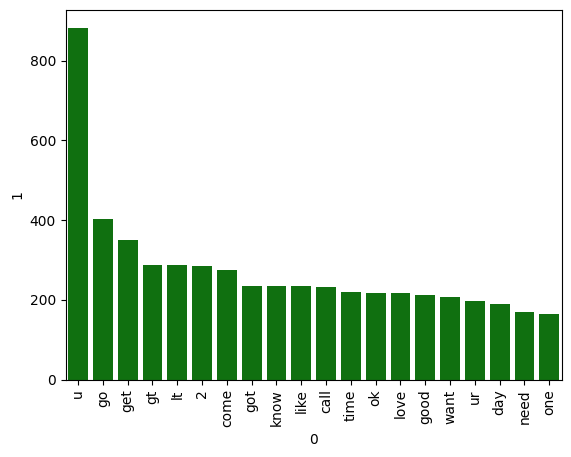

In [128]:
df_ham_top_w = pd.DataFrame(Counter(ham_top_w).most_common(20))
sns.barplot(x=0,y=1,data=df_ham_top_w, color='green')
plt.xticks(rotation = 'vertical')
plt.show()

# **Build the Model**

In [129]:
# vectorize the text column because text column must be in numbers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [130]:
X = tfidf.fit_transform(df['processed_text']).toarray()
print(X)
print(X.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(5169, 3000)


In [131]:
y = df['target'].values
print(y)
print(y.shape)

[0 0 1 ... 0 0 0]
(5169,)


**Split The Dataset by 80/20 rule**

In [132]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

**Fit the Model**

In [133]:
# select the algorithms to train model
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [134]:
gnb.fit(X_train, y_train)
y_predict_gnb = gnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_gnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_gnb))
print("Precision score  : " , precision_score(y_test, y_predict_gnb))

accuracy score   :  0.874274661508704
confusion matrix :
  [[790 106]
 [ 24 114]]
Precision score  :  0.5181818181818182


In [135]:
mnb.fit(X_train, y_train)
y_predict_mnb = mnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_mnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_mnb))
print("Precision score  : " , precision_score(y_test, y_predict_mnb))

accuracy score   :  0.9709864603481625
confusion matrix :
  [[896   0]
 [ 30 108]]
Precision score  :  1.0


In [136]:
bnb.fit(X_train, y_train)
y_predict_bnb = bnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_bnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_bnb))
print("Precision score  : " , precision_score(y_test, y_predict_bnb))

accuracy score   :  0.9835589941972921
confusion matrix :
  [[895   1]
 [ 16 122]]
Precision score  :  0.991869918699187


In [137]:
# try to Train the model on different algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

In [138]:
# initialize the algorithms
lr = LogisticRegression(solver='liblinear', penalty='l1')
svc = SVC(kernel = 'sigmoid', gamma=1.0)
linear_svc = LinearSVC(random_state=0, tol=1e-5)
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
bgc  = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [139]:
# make classifiers dictionary
classifiers = {
    'LogisticRegression'         : lr,
    'SVC'                        : svc,
    'LinearSVC'                  : linear_svc,
    'MultinomialNB'              : mnb,
    'DecisionTreeClassifier'     : dtc,
    'KNeighborsClassifier'       : knc,
    'RandomForestClassifier'     : rfc,
    'AdaBoostClassifier'         : abc,
    'GradientBoostingClassifier' : gbc,
    'BaggingClassifier'          : bgc,
    'ExtraTreesClassifier'       : etc,
    'XGBClassifier'              : xgb
}

In [140]:
# make a function that predict train data and test data and find sccuracy score and precision for all selected algorithms
def train_classifier_f(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision


In [141]:
accuracy_scores = []
precision_scores = []

for name, clf in classifiers.items():
        current_accuracy, current_precision = train_classifier_f(clf, X_train,y_train, X_test, y_test)

        print("For" , name)
        print("Accuracy" , current_accuracy)
        print("Precision" , current_precision)

        accuracy_scores.append(current_accuracy)
        precision_scores.append(current_precision)


For LogisticRegression
Accuracy 0.9555125725338491
Precision 0.96
For SVC
Accuracy 0.9758220502901354
Precision 0.9747899159663865
For LinearSVC
Accuracy 0.9777562862669246
Precision 0.967479674796748
For MultinomialNB
Accuracy 0.9709864603481625
Precision 1.0
For DecisionTreeClassifier
Accuracy 0.9303675048355899
Precision 0.83
For KNeighborsClassifier
Accuracy 0.9052224371373307
Precision 1.0
For RandomForestClassifier
Accuracy 0.9738878143133463
Precision 0.9826086956521739
For AdaBoostClassifier
Accuracy 0.9216634429400387
Precision 0.8202247191011236
For GradientBoostingClassifier
Accuracy 0.9506769825918762
Precision 0.9306930693069307
For BaggingClassifier
Accuracy 0.9584139264990329
Precision 0.8682170542635659
For ExtraTreesClassifier
Accuracy 0.9748549323017408
Precision 0.9745762711864406
For XGBClassifier
Accuracy 0.9700193423597679
Precision 0.9572649572649573


In [142]:
# make data frame for accuracy score and precision
performance_df = pd.DataFrame({'Algorithm':classifiers.keys(),
                             'Accuracy':accuracy_scores,
                             'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df = performance_df.set_index('Algorithm')
performance_df.head(10)

,Accuracy,Precision
Algorithm,,
MultinomialNB,0.970986,1.000000
KNeighborsClassifier,0.905222,1.000000
RandomForestClassifier,0.973888,0.982609
SVC,0.975822,0.974790
ExtraTreesClassifier,0.974855,0.974576
LinearSVC,0.977756,0.967480
LogisticRegression,0.955513,0.960000
XGBClassifier,0.970019,0.957265
GradientBoostingClassifier,0.950677,0.930693


# I Select the Model 'multinomialNM' with Tfidf vectorizer
because

*   text dataset more rely on precision is 100%
*   Accuracy is also nearest 100%




In [145]:
# Save the model
import joblib
joblib.dump(mnb, open('/content/drive/MyDrive/SpamHamModel/2nd-SpamHamEmailsTrainedModel.joblib', 'wb'))
joblib.dump(tfidf, open('/content/drive/MyDrive/SpamHamModel/vectorizerTfidf.joblib', 'wb'))